# TimeSeries Fluent API Examples

This notebook demonstrates the new chainable fluent API for TimeSeries analysis.

## Overview

The fluent API provides:
- **Chainable properties**: All reductions return TimeSeries objects
- **`.value` property**: Extract final values (like pandas)
- **`.shape` property**: Access data shape like numpy arrays
- **Bidirectional chaining**: Both ensemble→time and time→ensemble work
- **Generic filtering**: `filter(**kwargs)` accepts any Indexer parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from arte.time_series.time_series import TimeSeries
from arte.time_series.indexer import ModeIndexer

## Creating a Concrete TimeSeries Implementation

`TimeSeries` is an abstract base class. We need to implement the required methods:

In [2]:
class ModalTimeSeries(TimeSeries):
    """Concrete implementation of TimeSeries for modal coefficients."""
    
    def __init__(self, data, time, indexer):
        super().__init__()
        self._data = data
        self._time = time
        self._indexer = indexer
    
    def _get_not_indexed_data(self):
        # Return data in (time, ensemble) shape
        return self._data.T
    
    def get_index_of(self, *args, **kwargs):
        return self._indexer.modes(*args, **kwargs)
    
    def _get_time_vector(self):
        return self._time

## Creating Sample Data

In [3]:
# Create synthetic modal coefficients
n_modes = 10
n_frames = 100

time = np.linspace(0, 10, n_frames) * u.s
data = np.random.randn(n_modes, n_frames) * u.nm

# Add some sinusoidal trends
for i in range(n_modes):
    data[i] += 10 * np.sin(2 * np.pi * time.value / (i + 1)) * u.nm

ts = ModalTimeSeries(data, time=time, indexer=ModeIndexer(n_modes))
print(f"Created TimeSeries with shape: {ts.shape}")
print(f"  Time steps: {ts.shape[0]}")
print(f"  Modes: {ts.shape[1]}")

Created TimeSeries with shape: (100, 10)
  Time steps: 100
  Modes: 10


## Basic Chainable Operations

### Ensemble Operations

Compute statistics across the ensemble (spatial) dimension:

In [4]:
# Ensemble RMS (RMS across modes at each time)
ens_rms = ts.ensemble_rms
print(f"Ensemble RMS shape: {ens_rms.shape}")
print(f"Result is TimeSeries: {isinstance(ens_rms, TimeSeries)}")

# Ensemble mean
ens_mean = ts.ensemble_mean
print(f"\nEnsemble mean shape: {ens_mean.shape}")

# Ensemble standard deviation
ens_std = ts.ensemble_std
print(f"Ensemble std shape: {ens_std.shape}")

Ensemble RMS shape: (100,)
Result is TimeSeries: True

Ensemble mean shape: (100,)
Ensemble std shape: (100,)


### Time Operations

Compute statistics across the time dimension:

In [5]:
# Time mean (mean over time for each mode)
time_mean = ts.time_mean
print(f"Time mean shape: {time_mean.shape}")
print(f"Result is TimeSeries: {isinstance(time_mean, TimeSeries)}")

# Time RMS
time_rms = ts.time_rms
print(f"\nTime RMS shape: {time_rms.shape}")

# Time standard deviation
time_std = ts.time_std
print(f"Time std shape: {time_std.shape}")

Time mean shape: (1, 10)
Result is TimeSeries: True

Time RMS shape: (1, 10)
Time std shape: (1, 10)


## Chaining Operations

The real power: chain multiple operations together!

In [6]:
# Ensemble RMS, then time mean
mean_rms = ts.ensemble_rms.time_mean
print(f"Chained result shape: {mean_rms.shape}")
print(f"Chained result value: {mean_rms.value}")

# Time mean, then ensemble RMS (bidirectional!)
rms_mean = ts.time_mean.ensemble_rms
print(f"\nReversed chain shape: {rms_mean.shape}")
print(f"Reversed chain value: {rms_mean.value}")

Chained result shape: (1,)
Chained result value: 6.9890517132354 nm

Reversed chain shape: (1,)
Reversed chain value: 1.0172794024733252 nm


## Using .value to Extract Final Results

Like pandas, use `.value` to get the final array or scalar:

In [7]:
# Without .value: returns TimeSeries
result_ts = ts.ensemble_rms.time_mean
print(f"Type without .value: {type(result_ts)}")
print(f"Shape: {result_ts.shape}")

# With .value: extracts scalar or array
result_scalar = ts.ensemble_rms.time_mean.value
print(f"\nType with .value: {type(result_scalar)}")
print(f"Value: {result_scalar}")

Type without .value: <class 'arte.time_series.time_series.TimeSeries._create_temporal_reduced_series.<locals>.TemporalReducedTimeSeries'>
Shape: (1,)

Type with .value: <class 'astropy.units.quantity.Quantity'>
Value: 6.9890517132354 nm


## Filtering with filter()

Use `filter(**kwargs)` to select subsets before computing statistics:

In [8]:
# Filter to specific modes
low_modes = ts.filter(modes=[2, 3, 4])
print(f"Filtered shape: {low_modes.shape}")
print(f"Original had {ts.shape[1]} modes, filtered has {low_modes.shape[1]} modes")

# Chain filtering with operations
low_mode_rms = ts.filter(modes=[2, 3, 4]).ensemble_rms.time_mean.value
print(f"\nLow mode RMS: {low_mode_rms}")

# Compare with all modes
all_mode_rms = ts.ensemble_rms.time_mean.value
print(f"All mode RMS: {all_mode_rms}")
print(f"Difference: {all_mode_rms - low_mode_rms}")

Filtered shape: (100, 3)
Original had 10 modes, filtered has 3 modes

Low mode RMS: 6.980862943055743 nm
All mode RMS: 6.9890517132354 nm
Difference: 0.008188770179657467 nm


## Visualization Example

Plot ensemble RMS over time:

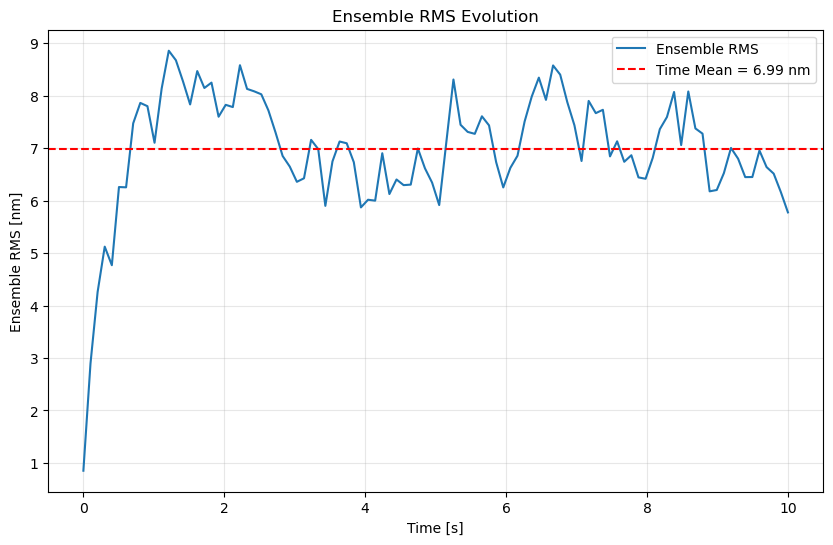

In [9]:
plt.figure(figsize=(10, 6))

# Ensemble RMS time series
ens_rms_ts = ts.ensemble_rms
time_array = ens_rms_ts.get_time_vector()
rms_array = np.array(ens_rms_ts)

plt.plot(time_array.value, rms_array, label='Ensemble RMS')

# Add time mean as horizontal line
mean_val = ens_rms_ts.time_mean.value
plt.axhline(mean_val.value if hasattr(mean_val, 'value') else mean_val, 
            color='r', linestyle='--', 
            label=f'Time Mean = {mean_val:.2f}')

plt.xlabel(f'Time [{time_array.unit}]')
plt.ylabel('Ensemble RMS [nm]')
plt.title('Ensemble RMS Evolution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Multiple Statistical Operations

In [10]:
# Compare different ensemble statistics
print("Ensemble statistics (time-averaged):")
print(f"  Mean:   {ts.ensemble_mean.time_mean.value:.2f}")
print(f"  RMS:    {ts.ensemble_rms.time_mean.value:.2f}")
print(f"  Std:    {ts.ensemble_std.time_mean.value:.2f}")
print(f"  Median: {ts.ensemble_median.time_mean.value:.2f}")
print(f"  PTP:    {ts.ensemble_ptp.time_mean.value:.2f}")

print("\nTime statistics (ensemble-averaged):")
print(f"  Mean:   {ts.time_mean.ensemble_mean.value:.2f}")
print(f"  RMS:    {ts.time_rms.ensemble_mean.value:.2f}")
print(f"  Std:    {ts.time_std.ensemble_mean.value:.2f}")
print(f"  Median: {ts.time_median.ensemble_mean.value:.2f}")
print(f"  PTP:    {ts.time_ptp.ensemble_mean.value:.2f}")

Ensemble statistics (time-averaged):
  Mean:   0.73 nm
  RMS:    6.99 nm
  Std:    6.25 nm
  Median: 1.10 nm
  PTP:    18.67 nm

Time statistics (ensemble-averaged):
  Mean:   0.73 nm
  RMS:    7.08 nm
  Std:    7.01 nm
  Median: 1.53 nm
  PTP:    22.67 nm


## Available Chainable Properties

### Ensemble Operations (reduce across spatial dimension):
- `ensemble_rms` - Root mean square
- `ensemble_mean` - Arithmetic mean (renamed from ensemble_average)
- `ensemble_std` - Standard deviation
- `ensemble_median` - Median
- `ensemble_ptp` - Peak-to-peak (max - min)

### Time Operations (reduce across temporal dimension):
- `time_mean` - Arithmetic mean (renamed from time_average)
- `time_std` - Standard deviation
- `time_rms` - Root mean square
- `time_median` - Median
- `time_ptp` - Peak-to-peak (max - min)

### Other Operations:
- `filter(**kwargs)` - Generic filtering (accepts any Indexer parameters)
- `with_times(time_array)` - Time filtering (alias for filter)
- `.value` - Extract final array or scalar (like pandas)
- `.shape` - Data shape (like numpy arrays)

## Migration from Legacy API

Old methods are deprecated but still work:

In [12]:
# OLD (deprecated - will show DeprecationWarning)
# old_result = ts.get_ensemble_average()

# NEW (fluent API - recommended)
new_result = ts.ensemble_mean.value

print(f"✓ New fluent API result: {new_result}")
print("\nMigration examples:")
print("  get_ensemble_average() → .ensemble_mean.value")
print("  get_time_rms()         → .time_rms.value")
print("  get_ensemble_rms()     → .ensemble_rms.value")

✓ New fluent API result: [ 2.19996641e-01  2.09961742e+00  3.39490256e+00  4.27030948e+00
  4.30766264e+00  5.39150272e+00  4.54710282e+00  4.61826564e+00
  5.56762980e+00  6.37042634e+00  6.17383133e+00  7.25962883e+00
  7.55555086e+00  6.78807454e+00  5.84779210e+00  5.04213240e+00
  4.26189119e+00  3.22072931e+00  3.92292829e+00  3.71903052e+00
  4.93126120e+00  5.28521852e+00  5.71435941e+00  4.82830317e+00
  4.60360876e+00  3.89192590e+00  2.36012089e+00  1.44232510e+00
  1.02092429e+00  1.41482834e+00  1.50927069e+00  9.95677055e-01
  1.25304243e+00  8.17327675e-01  4.54282902e-01 -7.44360444e-01
 -1.16676334e+00 -1.46087813e+00 -1.57683023e+00 -7.92364703e-01
 -7.01484761e-02  3.01235724e-01  4.79947579e-01  5.27316444e-01
  4.84123606e-02 -1.36402558e+00 -2.31070676e+00 -1.88144724e+00
 -2.84222952e+00 -2.31072486e+00 -2.01165688e+00 -2.30940016e+00
 -2.94188622e+00 -2.77933510e+00 -3.57812926e+00 -4.49737467e+00
 -4.77377487e+00 -4.48371066e+00 -3.96078727e+00 -3.13186344e+00


## Summary

The fluent API provides:

✅ **Expressive**: `ts.filter(modes=[2,3]).ensemble_rms.time_mean.value`

✅ **Chainable**: All operations return TimeSeries until `.value` extraction

✅ **Bidirectional**: Both ensemble→time and time→ensemble work

✅ **Flexible**: Generic `filter(**kwargs)` accepts any Indexer parameters

✅ **Familiar**: `.value` property like pandas, `.shape` like numpy

See the [TimeSeries API documentation](../../time_series.html) for complete details.